<a href="https://colab.research.google.com/github/Nicolas-Bernal/Simulacion-Estadistica/blob/main/Primer%20Corte/04_Metodo_aceptacion_y_rechazo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nicolas Alexander Bernal Rubio

## Simulacion Estadistica

# *Generacion De Variables Aleatorias *


In [16]:
install.packages("rmutil")
library(rmutil)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘rmutil’


The following object is masked from ‘package:stats’:

    nobs


The following objects are masked from ‘package:base’:

    as.data.frame, units




## Metodo Inversa (repaso)

$$f(x) \longrightarrow F(x) \longrightarrow U = F(x), \quad U \sim U(0,1)$$

$$\longrightarrow X = F^{-1}(U)$$

$$f(x) = \frac{1}{(b-a)} \mathbb{I}_{(a, b)} \quad \text{f.d.p. de } X \sim U(a, b)$$

*(Función Indicadora)*

$$F(x) = \int_{a}^{x} \frac{1}{(b-a)} dt = \frac{(x-a)}{(b-a)}$$

$$U = \frac{(x-a)}{(b-a)}$$

$$U(b-a) = x-a$$

$$U(b-a)+a = x$$





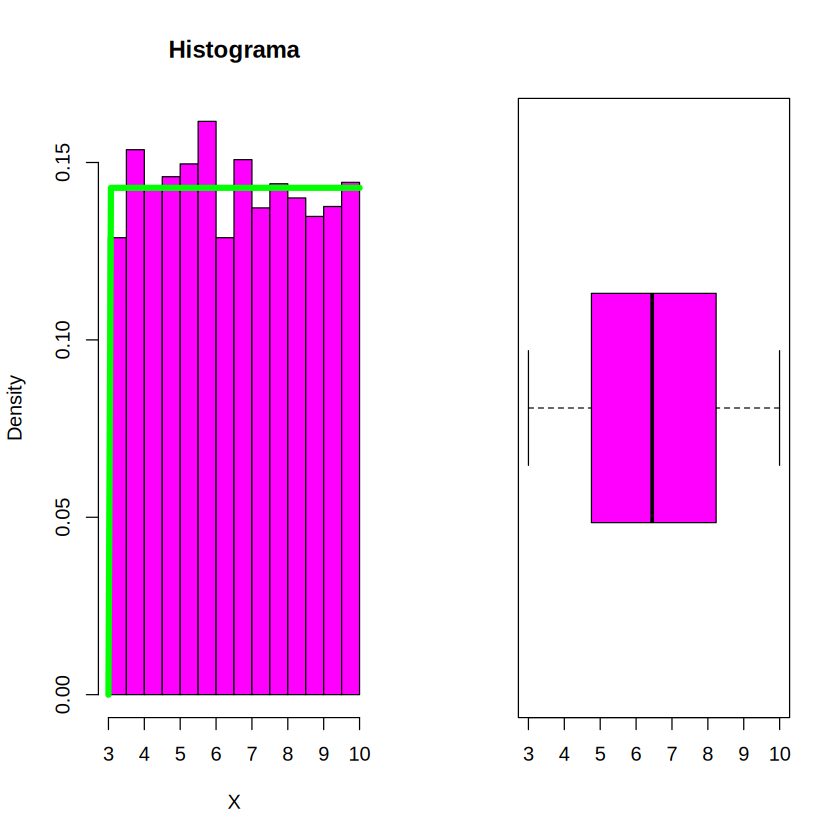

In [13]:
genunif = function(nsim,a,b){
  u = runif(nsim,0,1)
  x = u*(b-a)+a
  return(x)
}

X = genunif(5000,3,10)

par(mfrow = c(1,2))
hist(X,freq = FALSE,breaks = "FD",col = "magenta",main = "Histograma")
curve(dunif(x,3,10),add = TRUE,col = "green",lwd = 5)
boxplot(X,horizontal = TRUE,col = "magenta")

## Metodo de Aceptacion y Rechazo

* $f(x)$: función de interés
* $g(x)$: función auxiliar o instrumental
* $M$: constante

$$M = \max \left\{ \frac{f(x)}{g(x)} \right\}$$

$$f(x) \le g(x) \cdot M \quad \forall x$$

**Tasa de Aceptación:**

$$\text{Tasa de Aceptación} = \frac{\# \text{ de puntos que se aceptan}}{\# \text{ total de puntos}}$$



	Shapiro-Wilk normality test

data:  N
W = 0.99978, p-value = 0.9209


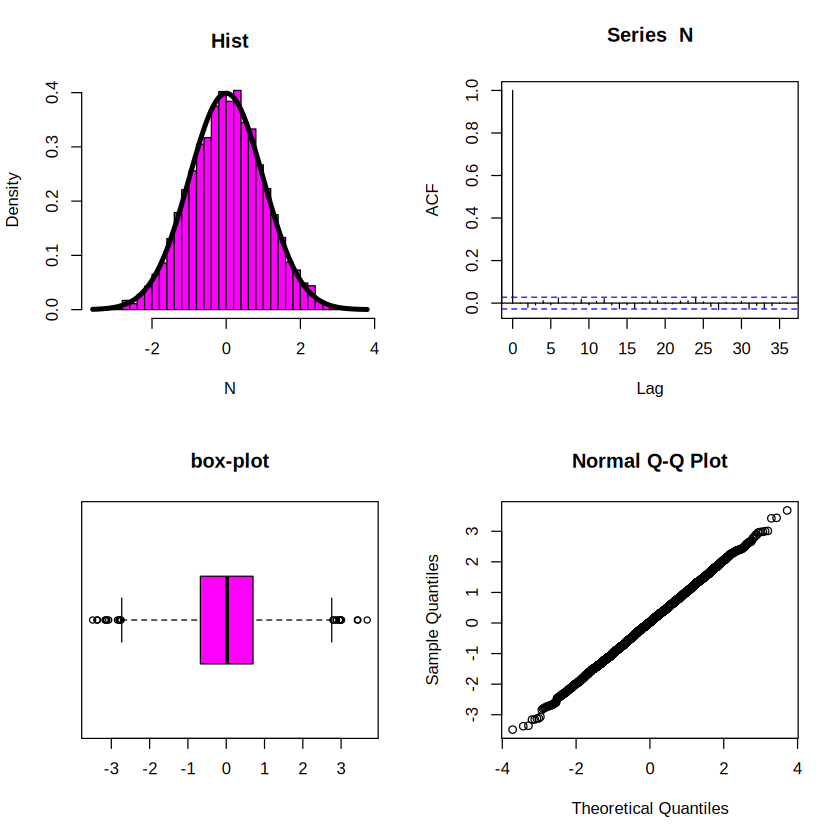

In [26]:


genNorm = function(nsim){
  k = 0
  j = 0
  M = 1.315489

  X = numeric(nsim)

  while(k < nsim){
    Y = rlaplace(1,0,1)
    U = runif(1,0,1)
    j = j + 1

    if (U <= dnorm(Y,0,1)/(dlaplace(Y,0,1)*M)){
      k = k + 1
      X[k] = Y
    }
  }
  return(X)
}

N = genNorm(5000)
par(mfrow = c(2,2))
hist(N,freq = FALSE,breaks = "FD",col = "magenta",main = "Hist")
curve(dnorm(x,0,1),add = TRUE,col = "black",lwd = 4)
acf(N)
boxplot(N,horizontal = TRUE,col = "magenta",main = "box-plot")
qqnorm(N)

shapiro.test(N)